In [2]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Resizing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. بارگذاری دیتاست CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 2. ساخت generator برای نرمال‌سازی
train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

batch_size = 128

# 3. ساخت generator
train_generator = train_gen.flow(x_train, y_train_cat, batch_size=batch_size, shuffle=True)
test_generator = test_gen.flow(x_test, y_test_cat, batch_size=batch_size, shuffle=False)

# 4. بارگذاری مدل پایه (بدون لایه‌های بالا)
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze کردن

# 5. ساخت مدل نهایی با resize داخلی
inputs = Input(shape=(32, 32, 3))
x = Resizing(299, 299)(inputs)  # تغییر سایز داخل مدل
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

# 6. کامپایل و آموزش
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_generator, epochs=5, validation_data=test_generator)

# 7. پیش‌بینی و ارزیابی
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# 8. گزارش‌ها
print("\n✅ Accuracy:", np.mean(y_pred == y_true))
print("\n📊 Classification Report:\n", classification_report(y_true, y_pred))

# 9. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Epoch 1/5
391/391 [==============================] - 322s 802ms/step - loss: 0.6719 - accuracy: 0.7799 - val_loss: 0.5354 - val_accuracy: 0.8173
Epoch 2/5
391/391 [==============================] - 313s 800ms/step - loss: 0.4803 - accuracy: 0.8348 - val_loss: 0.4894 - val_accuracy: 0.8346
Epoch 3/5
391/391 [==============================] - 348s 890ms/step - loss: 0.4376 - accuracy: 0.8514 - val_loss: 0.4783 - val_accuracy: 0.8382
Epoch 4/5
153/391 [==========>...................] - ETA: 8:59 - loss: 0.4126 - accuracy: 0.8596

KeyboardInterrupt: 

Epoch 1/5
1563/1563 [==============================] - 7s 3ms/step - loss: 1.6261 - accuracy: 0.4036 - val_loss: 1.2833 - val_accuracy: 0.5399
Epoch 2/5
1563/1563 [==============================] - 5s 3ms/step - loss: 1.2742 - accuracy: 0.5501 - val_loss: 1.1693 - val_accuracy: 0.5812
Epoch 3/5
1563/1563 [==============================] - 5s 3ms/step - loss: 1.1045 - accuracy: 0.6129 - val_loss: 0.9868 - val_accuracy: 0.6527
Epoch 4/5
1563/1563 [==============================] - 5s 3ms/step - loss: 0.9984 - accuracy: 0.6521 - val_loss: 0.9075 - val_accuracy: 0.6836
Epoch 5/5
313/313 [==============================] - 0s 1ms/step

✅ Accuracy: 0.7019

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.66      0.71      1000
           1       0.88      0.78      0.83      1000
           2       0.66      0.55      0.60      1000
           3       0.50      0.56      0.53      1000
           4       0.61      0.72      0.66  

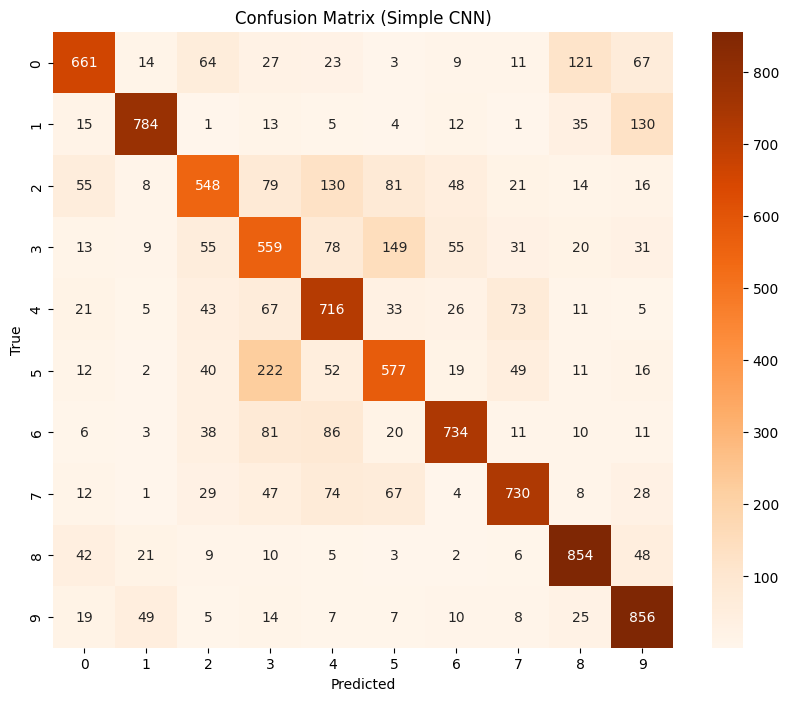

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. بارگذاری داده‌ها
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 2. نرمال‌سازی داده‌ها با ImageDataGenerator
train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

batch_size = 32
train_generator = train_gen.flow(x_train, y_train_cat, batch_size=batch_size, shuffle=True)
test_generator = test_gen.flow(x_test, y_test_cat, batch_size=batch_size, shuffle=False)

# 3. تعریف مدل ساده CNN
model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(128, (3,3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# 4. کامپایل مدل
model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. آموزش مدل
model_cnn.fit(train_generator, epochs=5, validation_data=test_generator)

# 6. ارزیابی
y_pred_probs = model_cnn.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

print("\n✅ Accuracy:", np.mean(y_pred == y_true))
print("\n📊 Classification Report:\n", classification_report(y_true, y_pred))

# 7. ماتریس درهم‌ریختگی
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix (Simple CNN)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import numpy as np

# بارگذاری داده‌ها
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# ----------- مدل 1: InceptionV3 -----------

# تعریف dataset برای InceptionV3 با resize
def prepare_incep_dataset(x, y, batch_size=32):
    def preprocess(img, label):
        img = tf.image.resize(img, (299, 299))
        img = preprocess_input(img)
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_incep = prepare_incep_dataset(x_train, y_train_cat)
test_ds_incep = prepare_incep_dataset(x_test, y_test_cat)

# ساخت مدل InceptionV3
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False

model_incep = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_incep.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

print("\n🔧 در حال آموزش مدل InceptionV3...")
model_incep.fit(train_ds_incep, epochs=5, verbose=2)
test_loss_incep, test_acc_incep = model_incep.evaluate(test_ds_incep, verbose=0)
print(f"✅ دقت InceptionV3 روی داده تست: {test_acc_incep:.4f}")

# ----------- مدل 2: CNN ساده -----------

# نرمال‌سازی
x_train_small = x_train / 255.0
x_test_small = x_test / 255.0

model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("\n🔧 در حال آموزش مدل CNN ساده...")
model_cnn.fit(x_train_small, y_train_cat, epochs=5, batch_size=32, validation_split=0.1, verbose=2)
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_small, y_test_cat, verbose=0)
print(f"✅ دقت CNN ساده روی داده تست: {test_acc_cnn:.4f}")

# ----------- مقایسه -----------

print("\n📊 مقایسه نهایی دقت مدل‌ها روی تست:")
print(f"✔️ InceptionV3 accuracy: {test_acc_incep:.4f}")
print(f"✔️ Simple CNN accuracy : {test_acc_cnn:.4f}")



🔧 در حال آموزش مدل InceptionV3...
Epoch 1/5
1563/1563 - 290s - loss: 0.5940 - accuracy: 0.8031 - 290s/epoch - 186ms/step
Epoch 2/5
1563/1563 - 288s - loss: 0.4786 - accuracy: 0.8386 - 288s/epoch - 184ms/step
Epoch 3/5
1563/1563 - 289s - loss: 0.4460 - accuracy: 0.8502 - 289s/epoch - 185ms/step
Epoch 4/5
1563/1563 - 283s - loss: 0.4218 - accuracy: 0.8577 - 283s/epoch - 181ms/step
Epoch 5/5
1563/1563 - 285s - loss: 0.4053 - accuracy: 0.8627 - 285s/epoch - 182ms/step
✅ دقت InceptionV3 روی داده تست: 0.8695

🔧 در حال آموزش مدل CNN ساده...
Epoch 1/5
1407/1407 - 4s - loss: 1.4822 - accuracy: 0.4684 - val_loss: 1.2442 - val_accuracy: 0.5500 - 4s/epoch - 3ms/step
Epoch 2/5
1407/1407 - 3s - loss: 1.1376 - accuracy: 0.6006 - val_loss: 1.0308 - val_accuracy: 0.6342 - 3s/epoch - 2ms/step
Epoch 3/5
1407/1407 - 3s - loss: 1.0037 - accuracy: 0.6504 - val_loss: 0.9605 - val_accuracy: 0.6640 - 3s/epoch - 2ms/step
Epoch 4/5
1407/1407 - 3s - loss: 0.9240 - accuracy: 0.6772 - val_loss: 0.9573 - val_accura


🔧 در حال آموزش مدل InceptionV3...
Epoch 1/5
1563/1563 - 286s - loss: 0.6010 - accuracy: 0.8007 - 286s/epoch - 183ms/step
Epoch 2/5
1563/1563 - 287s - loss: 0.4813 - accuracy: 0.8392 - 287s/epoch - 184ms/step
Epoch 3/5
1563/1563 - 286s - loss: 0.4518 - accuracy: 0.8499 - 286s/epoch - 183ms/step
Epoch 4/5
1563/1563 - 283s - loss: 0.4253 - accuracy: 0.8570 - 283s/epoch - 181ms/step
Epoch 5/5
1563/1563 - 287s - loss: 0.4076 - accuracy: 0.8639 - 287s/epoch - 183ms/step

✅ دقت InceptionV3: 0.8748
313/313 [==============================] - 57s 181ms/step

📊 گزارش طبقه‌بندی InceptionV3:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      1000
           1       0.93      0.94      0.93      1000
           2       0.88      0.83      0.85      1000
           3       0.74      0.82      0.78      1000
           4       0.85      0.84      0.85      1000
           5       0.88      0.81      0.84      1000
           6       0.87      0.90 

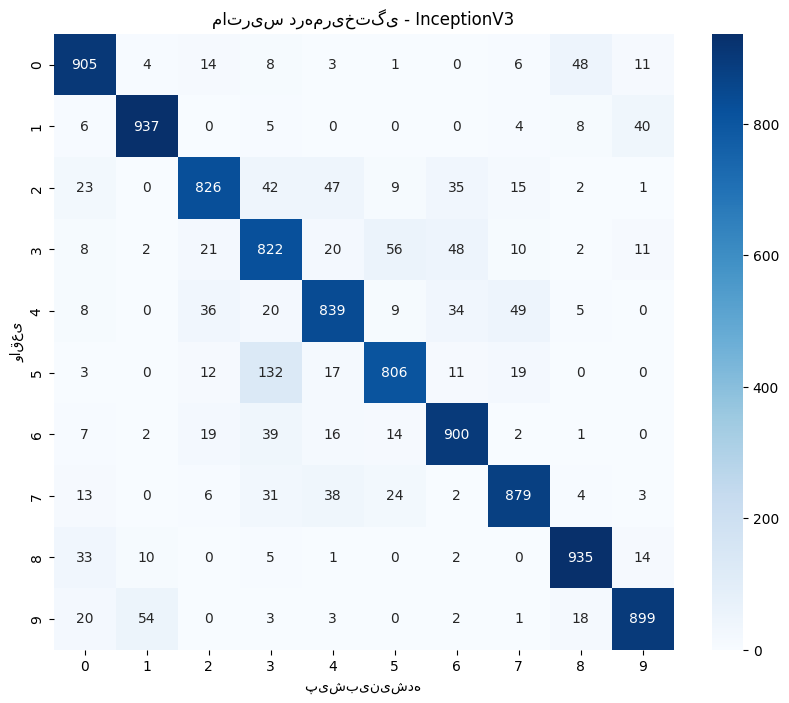


🔧 در حال آموزش مدل CNN ساده...
Epoch 1/5
1407/1407 - 4s - loss: 1.4761 - accuracy: 0.4706 - val_loss: 1.2167 - val_accuracy: 0.5728 - 4s/epoch - 3ms/step
Epoch 2/5
1407/1407 - 3s - loss: 1.1210 - accuracy: 0.6080 - val_loss: 1.0644 - val_accuracy: 0.6368 - 3s/epoch - 2ms/step
Epoch 3/5
1407/1407 - 3s - loss: 0.9842 - accuracy: 0.6565 - val_loss: 1.0200 - val_accuracy: 0.6482 - 3s/epoch - 2ms/step
Epoch 4/5
1407/1407 - 3s - loss: 0.8925 - accuracy: 0.6916 - val_loss: 0.9195 - val_accuracy: 0.6854 - 3s/epoch - 2ms/step
Epoch 5/5
1407/1407 - 3s - loss: 0.8187 - accuracy: 0.7158 - val_loss: 0.9224 - val_accuracy: 0.6824 - 3s/epoch - 2ms/step

✅ دقت CNN ساده: 0.6704
313/313 [==============================] - 0s 1ms/step

📊 گزارش طبقه‌بندی CNN ساده:
              precision    recall  f1-score   support

           0       0.64      0.78      0.70      1000
           1       0.85      0.69      0.77      1000
           2       0.56      0.55      0.55      1000
           3       0.54     

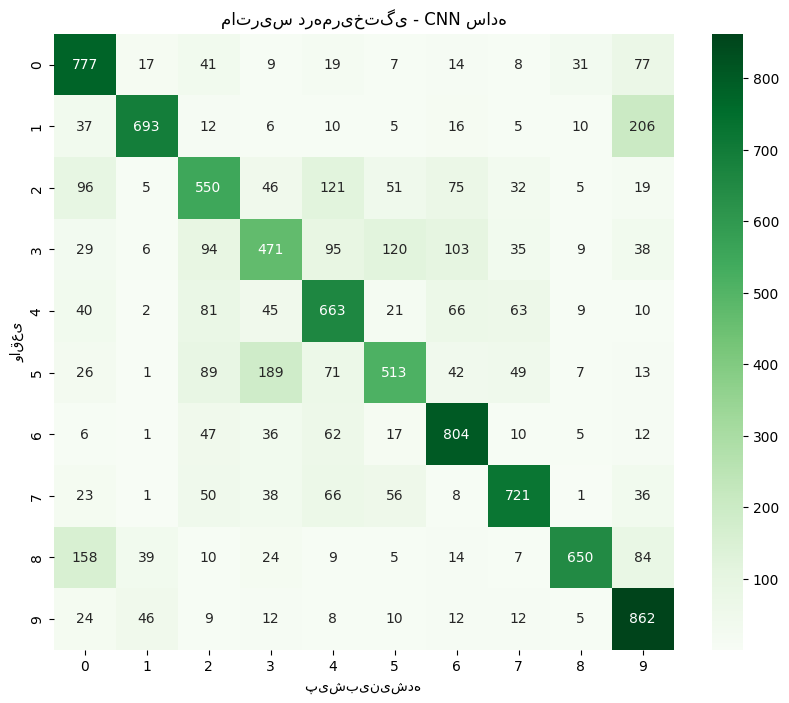


📈 مقایسه دقت دو مدل:
✔️ InceptionV3 Accuracy: 0.8748
✔️ Simple CNN Accuracy : 0.6704


In [3]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------- داده‌ها ------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# -------- آماده‌سازی داده برای Inception --------
def prepare_incep_dataset(x, y, batch_size=32):
    def preprocess(img, label):
        img = tf.image.resize(img, (299, 299))
        img = preprocess_input(img)
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_incep = prepare_incep_dataset(x_train, y_train_cat)
test_ds_incep = prepare_incep_dataset(x_test, y_test_cat)

# -------- مدل InceptionV3 --------
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # می‌تونی True بذاری برای Fine-tune

model_incep = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_incep.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n🔧 در حال آموزش مدل InceptionV3...")
model_incep.fit(train_ds_incep, epochs=5, verbose=2)
test_loss_incep, test_acc_incep = model_incep.evaluate(test_ds_incep, verbose=0)
print(f"\n✅ دقت InceptionV3: {test_acc_incep:.4f}")

# پیش‌بینی و ارزیابی
y_pred_incep = model_incep.predict(test_ds_incep)
y_pred_classes_incep = np.argmax(y_pred_incep, axis=1)

print("\n📊 گزارش طبقه‌بندی InceptionV3:")
print(classification_report(y_test, y_pred_classes_incep))

conf_mat_incep = confusion_matrix(y_test, y_pred_classes_incep)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat_incep, annot=True, fmt='d', cmap='Blues')
plt.title("ماتریس درهم‌ریختگی - InceptionV3")
plt.xlabel("پیش‌بینی‌شده")
plt.ylabel("واقعی")
plt.show()

# -------- مدل CNN ساده --------
x_train_small = x_train / 255.0
x_test_small = x_test / 255.0

model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n🔧 در حال آموزش مدل CNN ساده...")
model_cnn.fit(x_train_small, y_train_cat, epochs=5, batch_size=32, validation_split=0.1, verbose=2)
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_small, y_test_cat, verbose=0)
print(f"\n✅ دقت CNN ساده: {test_acc_cnn:.4f}")

# پیش‌بینی و ارزیابی
y_pred_cnn = model_cnn.predict(x_test_small)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)

print("\n📊 گزارش طبقه‌بندی CNN ساده:")
print(classification_report(y_test, y_pred_classes_cnn))

conf_mat_cnn = confusion_matrix(y_test, y_pred_classes_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat_cnn, annot=True, fmt='d', cmap='Greens')
plt.title("ماتریس درهم‌ریختگی - CNN ساده")
plt.xlabel("پیش‌بینی‌شده")
plt.ylabel("واقعی")
plt.show()

# -------- مقایسه نهایی --------
print("\n📈 مقایسه دقت دو مدل:")
print(f"✔️ InceptionV3 Accuracy: {test_acc_incep:.4f}")
print(f"✔️ Simple CNN Accuracy : {test_acc_cnn:.4f}")